In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy.io import loadmat
from scipy.spatial import procrustes

In [14]:
file = loadmat('./data/robustShapeMean2D.mat')
data = np.array(file['pointsets'])
data.shape

(357, 32, 2)

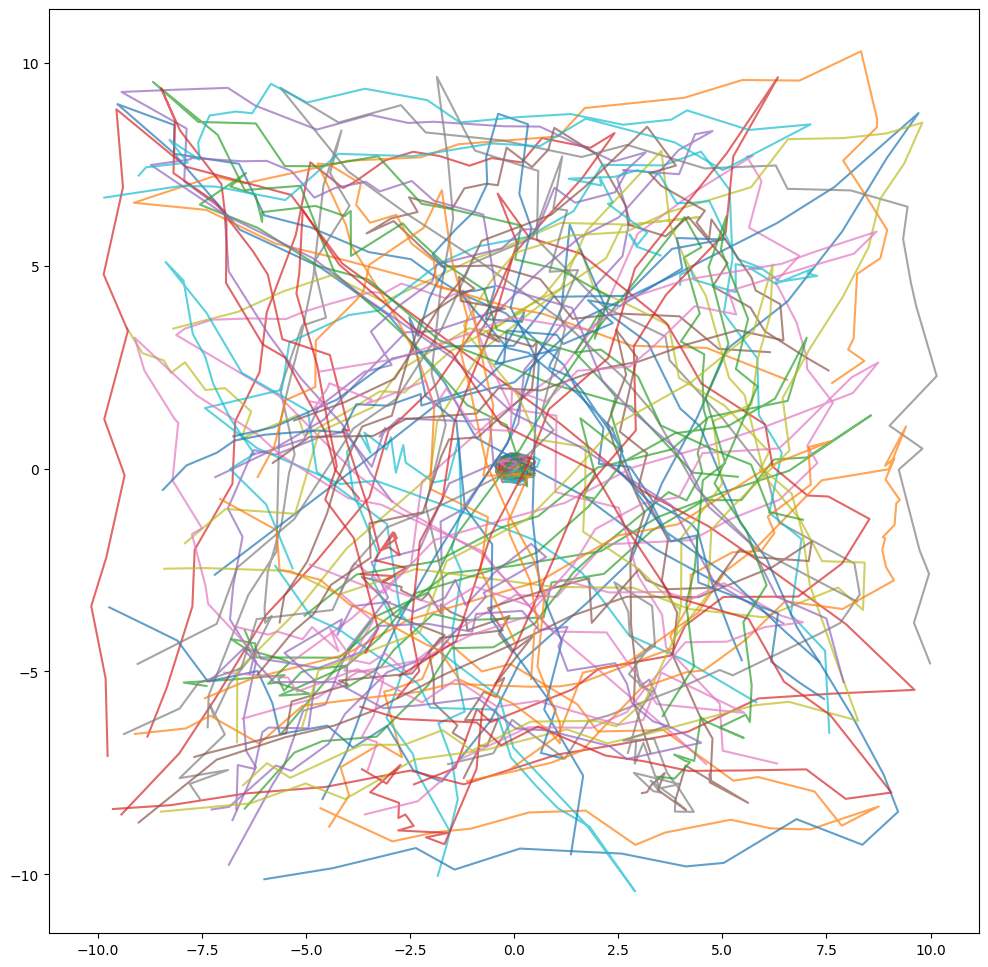

In [16]:
# display pointsets
plt.figure(figsize=(12, 12))
for i in range(data.shape[0]):
    points = data[i]
    plt.plot(points[:, 0], points[:, 1], label=f'Pointset {i}', alpha=0.7)

# plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()

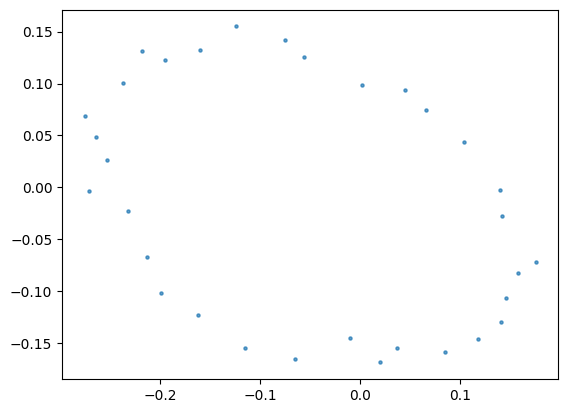

In [23]:
points = data[100]
plt.scatter(points[:, 0], points[:, 1], s = 5, label=f'Pointset {i}', alpha=0.7)

In [24]:
# doesn't assume shape 1 and shape 2 are in pre shape space
# shifts, scales and rotates shape 2 to best fit shape 1
def code2(shape1, shape2):

    n = shape1.shape[0]
    
    x1 = shape1[:, 0]  
    y1 = shape1[:, 1]  
    x2 = shape2[:, 0]  
    y2 = shape2[:, 1]  
    
    # solve: Ac = b where c = [tx, ty, a, b]^T
    
    A = np.zeros((4, 4))
    A[0, 0] = n
    A[0, 2] = -np.sum(x2)
    A[0, 3] = np.sum(y2)
    
    A[1, 1] = n
    A[1, 2] = -np.sum(y2)
    A[1, 3] = -np.sum(x2)
    
    A[2, 0] = np.sum(x2)
    A[2, 1] = np.sum(y2)
    A[2, 2] = -np.sum(x2*x2 + y2*y2)
    
    A[3, 0] = -np.sum(y2)
    A[3, 1] = np.sum(x2)
    A[3, 3] = -np.sum(x2*x2 + y2*y2)
    
    b = np.zeros(4)
    b[0] = np.sum(x1)
    b[1] = np.sum(y1)
    b[2] = np.sum(x1*x2 + y1*y2)
    b[3] = np.sum(y1*x2 - x1*y2)
    
    # solve the linear system
    c = np.linalg.solve(A, b)
    
    # get parameters from solution
    tx, ty, a, b = c

    a = -a
    b = -b
    
    # get scale and rotation from the solution
    s = np.sqrt(a*a + b*b)
    theta = np.arctan2(b, a)
    
    # construct the rotation matrix from theta
    R = np.array([[np.cos(theta), -np.sin(theta)], 
                  [np.sin(theta), np.cos(theta)]])
    
    # translation vector
    T = np.array([tx, ty])
    
    # transform shape 2 using the solution
    M = np.array([[a, -b], [b, a]]) 
    shape2_transformed = np.dot(shape2, M.T) + T
    
    # get the distance
    distance = np.linalg.norm(shape1 - shape2_transformed)
    
    return distance, T, s, R

In [54]:
def procrustes_l2(pointsets, max_iterations=1000, tolerance=1e-4):
    
    # initialize mean shape to the first pointset
    mean_shape = np.mean(pointsets, axis = 0)
    
    # center the initial mean
    centroid = np.mean(mean_shape, axis=0)
    mean_shape -= centroid
    mean_shape = mean_shape / np.sum(mean_shape**2)
    
    for iteration in tqdm(range(max_iterations)):

        # align shapes to current mean
        aligned_pointsets = []
        
        for pointset in pointsets:
            
            # get optimal scale, translation and rotation to apply to pointset to align best with mean shape
            _, T, s, R = code2(mean_shape, pointset)
            
            # apply the transformation to get the aligned pointset
            aligned_pointset = s * np.dot(pointset, R.T) + T
            aligned_pointsets.append(aligned_pointset)
        
        # Compute l2 distances
        distances = [np.linalg.norm(mean_shape - X)**2 for X in aligned_pointsets]
        distances = np.array(distances)

        # Avoid division by zero
        distances = np.maximum(distances, 1e-4)

        # Weighted mean update (Weiszfeld-style)
        weights = 1.0 / distances[:, np.newaxis, np.newaxis]
        weighted_sum = np.sum([w * X for w, X in zip(weights, aligned_pointsets)], axis=0)
        new_mean = weighted_sum / np.sum(weights)
        
        # early termination check
        if np.linalg.norm(new_mean - mean_shape) < tolerance:
            break
        
        # update the mean shape
        mean_shape = new_mean
        mean_shape = mean_shape / np.sum(mean_shape**2)

    
    return mean_shape, aligned_pointsets

In [57]:
def procrustes_l1(pointsets, max_iterations=10000, tolerance=1e-4):
    
    # initialize mean shape to the first pointset
    mean_shape = np.mean(pointsets, axis = 0)

    # center the initial mean
    centroid = np.mean(mean_shape, axis=0)
    mean_shape -= centroid
    mean_shape = mean_shape / np.sum(mean_shape**2)

    
    for iteration in tqdm(range(max_iterations)):

        # align shapes to current mean
        aligned_pointsets = []
        
        for pointset in pointsets:
            
            # get optimal scale, translation and rotation to apply to pointset to align best with mean shape
            _, T, s, R = code2(mean_shape, pointset)
            
            # apply the transformation to get the aligned pointset
            aligned_pointset = s * np.dot(pointset, R.T) + T
            aligned_pointsets.append(aligned_pointset)
                

        # minimize l1-norm by taking point-wise median
        # compute the new mean shape
        new_mean = np.median(aligned_pointsets, axis=0)
        
        # early termination check
        if np.linalg.norm(new_mean - mean_shape) < tolerance:
            break
        
        # update the mean shape
        mean_shape = new_mean
        mean_shape = mean_shape / np.sum(mean_shape**2)

    
    return mean_shape, aligned_pointsets

In [ ]:
# part a
ps1 = data.copy()
meanl2, alignedl2 = procrustes_l2(ps1)
plt.figure(figsize=(12, 20))
plt.subplot(2, 1, 1)
plt.title("Mean Shape l2")
plt.plot(meanl2[:, 0], meanl2[:, 1])
# plt.plot(mean1)
plt.subplot(2, 1, 2)
plt.title("Aligned pointsets")

for pointset in alignedl2:
    plt.scatter(pointset[:, 0], pointset[:, 0])


100%|██████████| 1000/1000 [00:36<00:00, 27.36it/s]


  3%|▎         | 272/10000 [00:08<05:21, 30.28it/s]


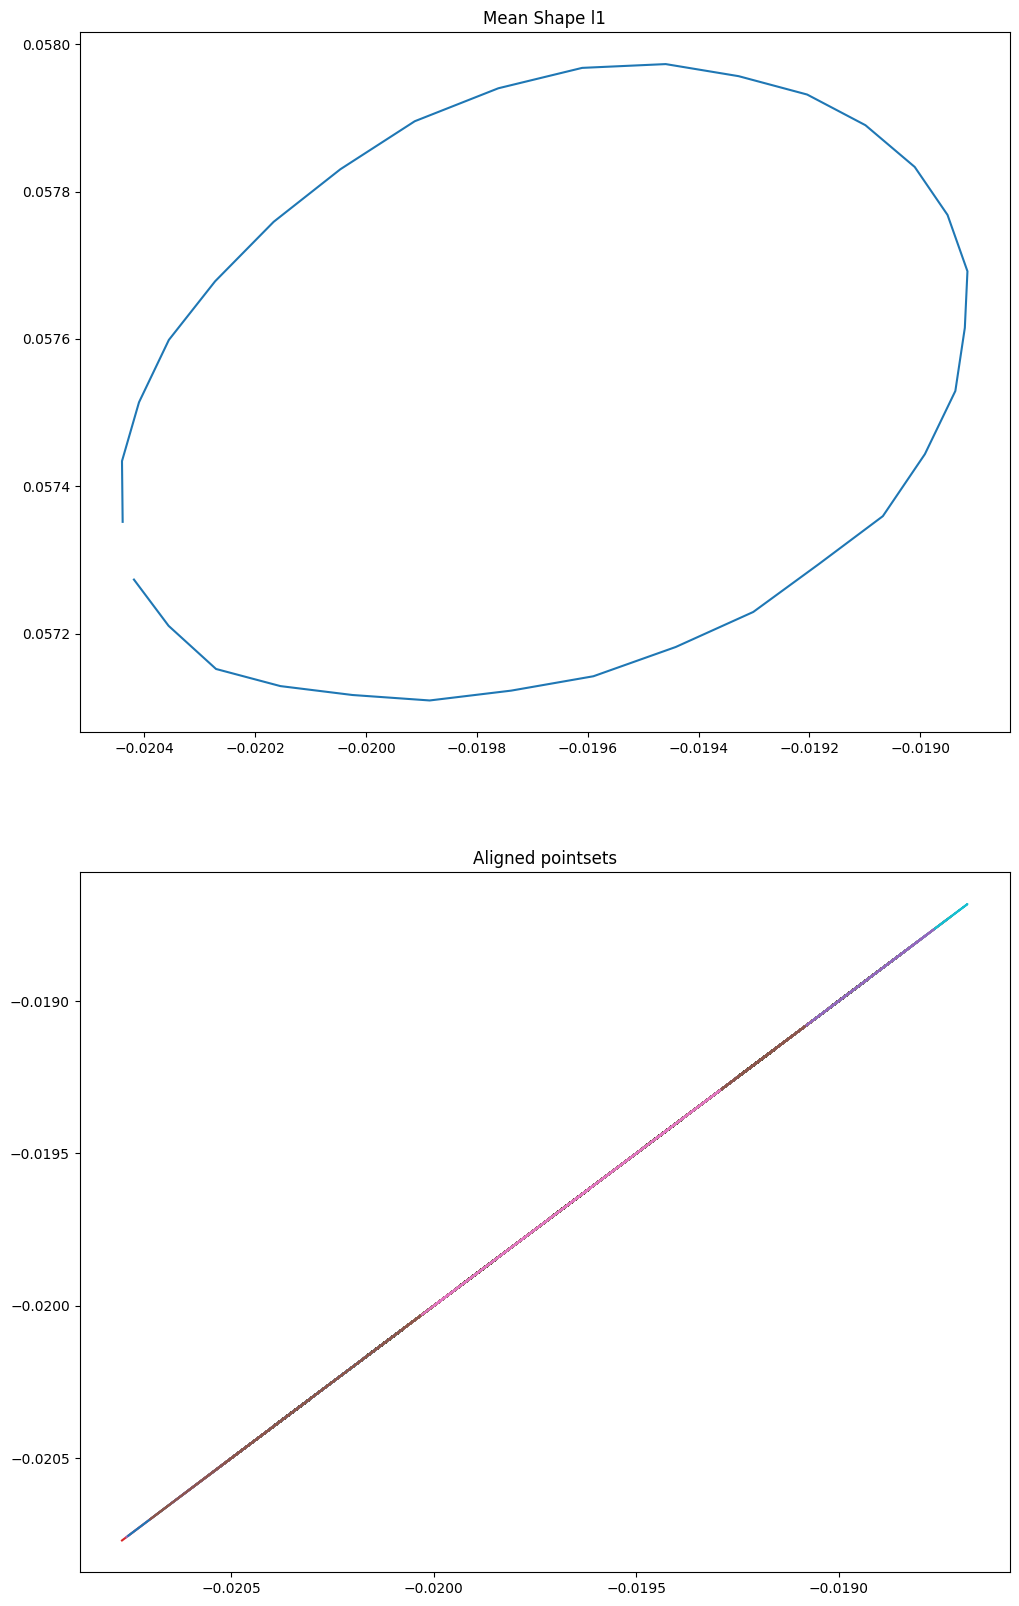

In [ ]:
# part a
ps2 = data.copy()
meanl1, alignedl1 = procrustes_l1(ps2)
plt.figure(figsize=(12, 20))
plt.subplot(2, 1, 1)
plt.title("Mean Shape l1")
plt.plot(meanl1[:, 0], meanl1[:, 1])
# plt.plot(mean1)
plt.subplot(2, 1, 2)
plt.title("Aligned pointsets")
for pointset in alignedl1:
    plt.plot(pointset[:, 0], pointset[:, 0])